Removed no burn in
Removed no burn in
Removed no burn in


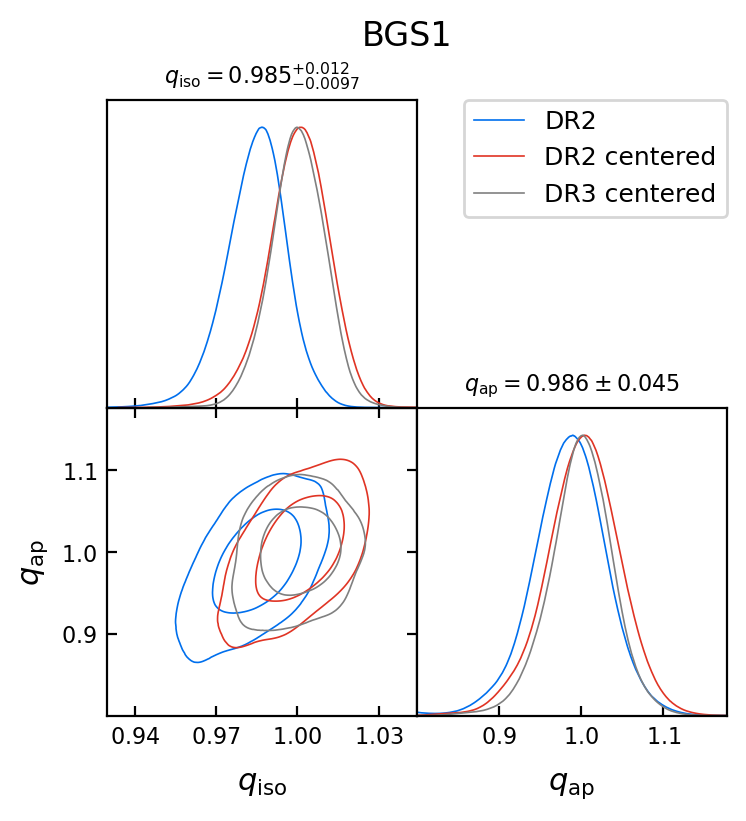

Removed no burn in
Removed no burn in
Removed no burn in


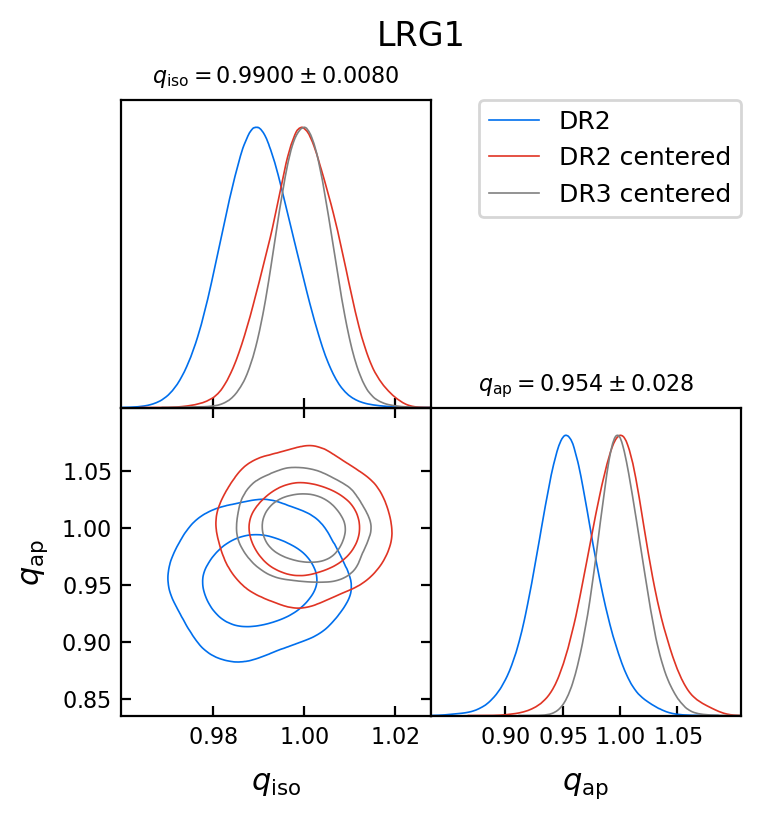

Removed no burn in
Removed no burn in
Removed no burn in


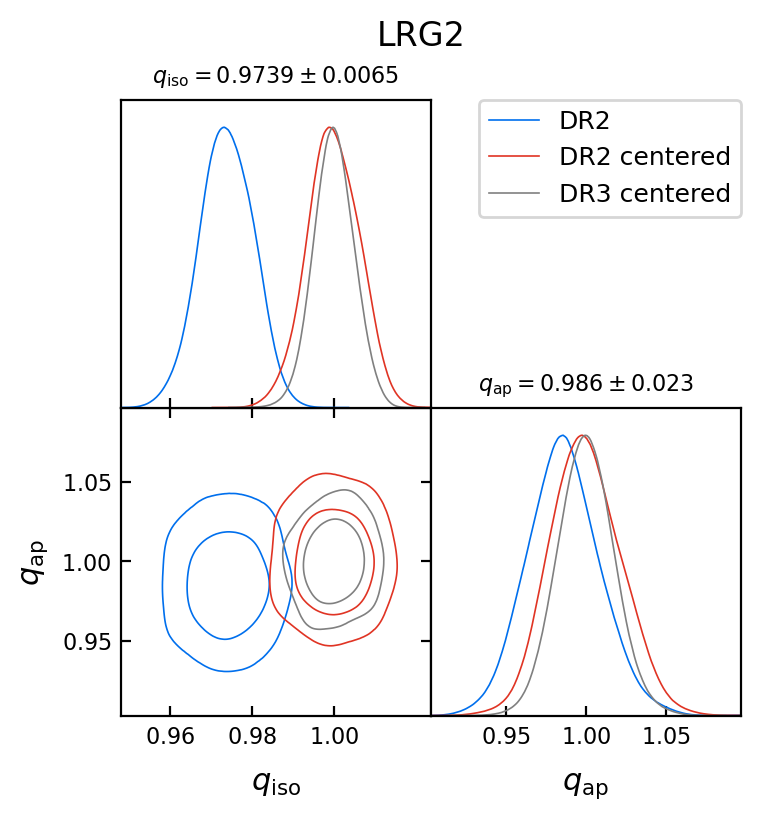

Removed no burn in
Removed no burn in
Removed no burn in


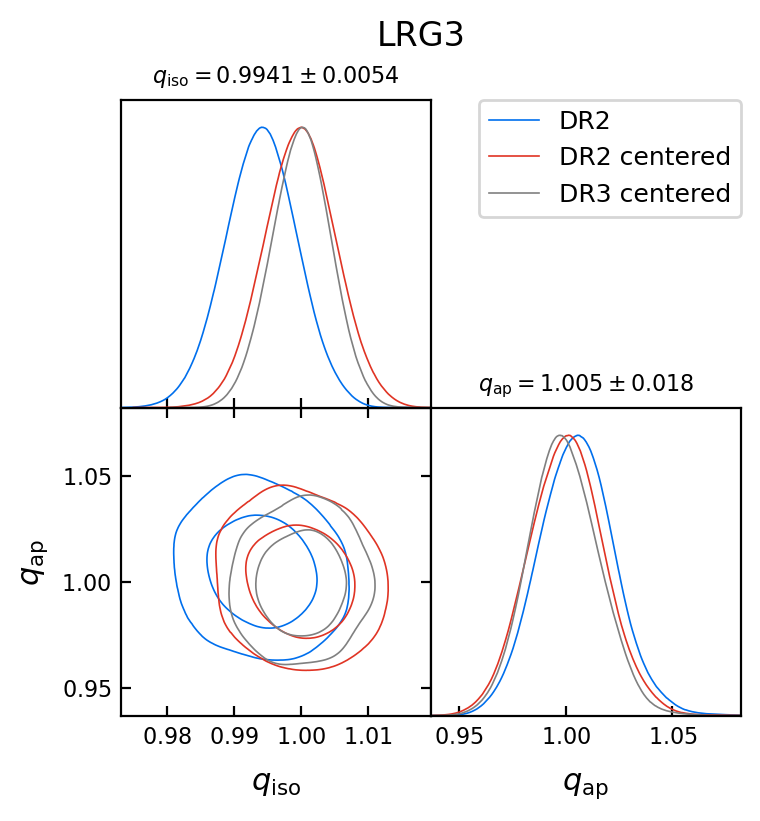

Removed no burn in
Removed no burn in
Removed no burn in


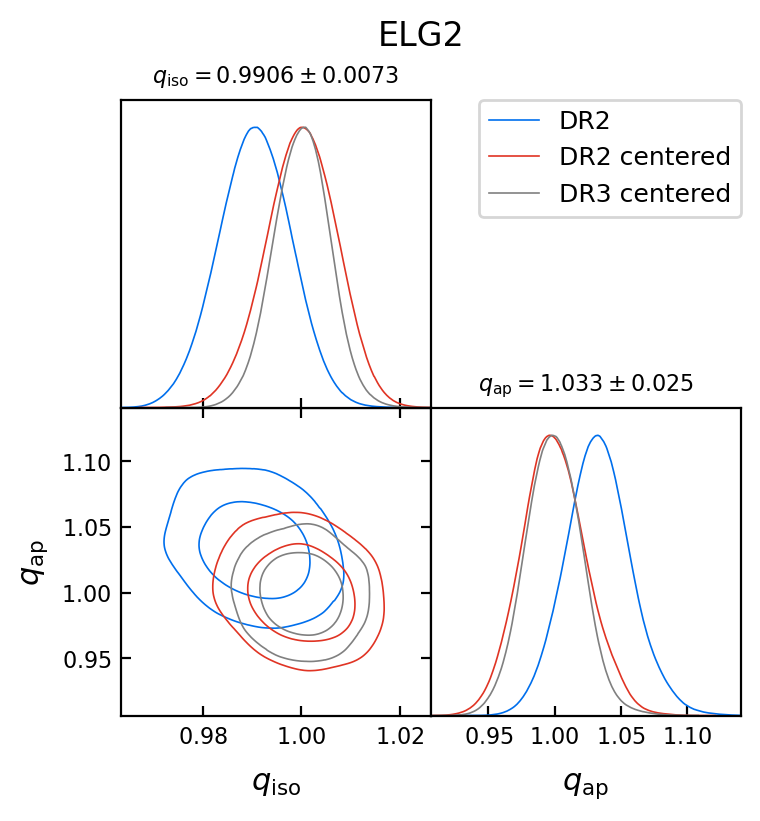

Removed no burn in
Removed no burn in
Removed no burn in


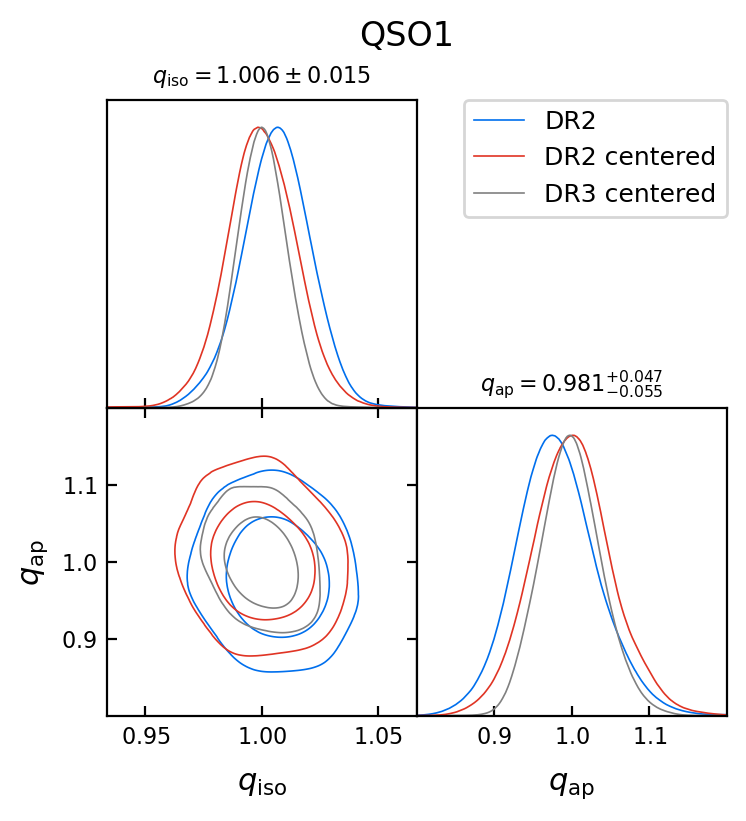

In [2]:
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from desilike.samples import MCSamples, Profiles, plotting
from cosmoprimo.fiducial import AbacusSummit

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

params_toplot = ['qiso', 'qap']

truth = {}


def read_samples(fn, burnin=False, thin=False):
    if isinstance(fn, list):
        samples = MCSamples.concatenate([MCSamples.read(fn).remove_burnin(burnin if burnin else 0.) for fn in fn])
    else:
        samples = MCSamples.read(fn)
    if thin:
        samples = samples[::thin]
    return samples


fits_dir = Path('/dvs_ro/cfs/cdirs/desi/science/cai/desi-clustering/dr2/fits/bao')
dir_dr2 = fits_dir / 'with_desi-clustering/data-dr2-v1.1'
dir_dr2_centered = fits_dir / 'centered_alpha/data-dr2-v1.1'
dir_dr3_centered = fits_dir / 'centered_alpha/data-dr3-matterhorn-v2-v0-bao'

stats = defaultdict(list)
tracers = []
for tracer, (basename_dr2, basename_dr3) in {'BGS1': ('template-bao_BGS1-z0p1-0p4-GCcomb-C2R-04031e03', 'template-bao_BGS1-z0p1-0p4-GCcomb-C2R-31837ac6'),
                                             'LRG1': ('template-bao_LRG1-z0p4-0p6-GCcomb-C2R-87f87260', 'template-bao_LRG1-z0p4-0p6-GCcomb-C2R-c100abcd'),
                                             'LRG2': ('template-bao_LRG2-z0p6-0p8-GCcomb-C2R-a9326aab', 'template-bao_LRG2-z0p6-0p8-GCcomb-C2R-6a927f07'),
                                             'LRG3': ('template-bao_LRG3-z0p8-1p1-GCcomb-C2R-ceab2a2e', 'template-bao_LRG3-z0p8-1p1-GCcomb-C2R-247dbe07'),
                                             'ELG2': ('template-bao_ELG2-z1p1-1p6-GCcomb-C2R-0813091f', 'template-bao_ELG2-z1p1-1p6-GCcomb-C2R-bdf67e3a'),
                                             'QSO1': ('template-bao_QSO1-z0p8-2p1-GCcomb-C2R-8eba6faa', 'template-bao_QSO1-z0p8-2p1-GCcomb-C2R-115ad56b')}.items():
    samples, legends = [], []
    samples.append(read_samples([dir_dr2 / f'{basename_dr2}/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.5, thin=10))
    legends.append('DR2')
    samples.append(read_samples([dir_dr2_centered / f'{basename_dr2}/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.5, thin=10))
    legends.append('DR2 centered')
    samples.append(read_samples([dir_dr3_centered / f'{basename_dr3}/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.5, thin=10))
    legends.append('DR3 centered')
    mean, cov = samples[-1].mean(params=params_toplot), samples[-1].covariance(params=params_toplot)
    plotting.plot_triangle(samples, params=params_toplot, title_limit=1, markers=truth, legend_labels=legends)
    fig = plt.gcf()
    fig.suptitle(tracer)
    plt.show()
    tracers.append(tracer)
    for sample, label in zip(samples, legends):
        stats[(label, 'qiso')].append(sample.std('qiso'))
        stats[(label, 'qap')].append(sample.std('qap'))

### Covariance comparison

Removed no burn in
Removed no burn in


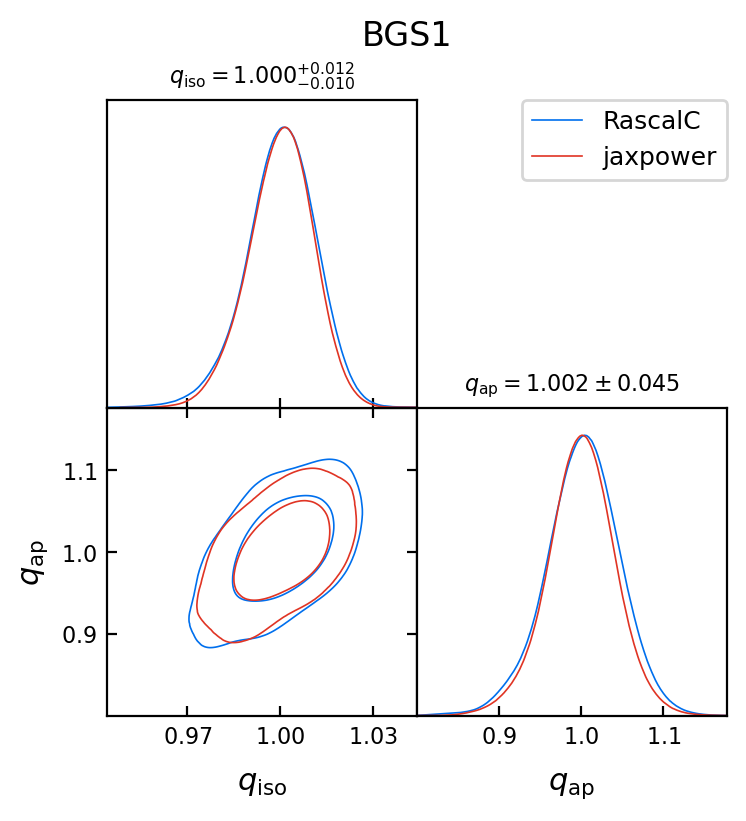

Removed no burn in
Removed no burn in


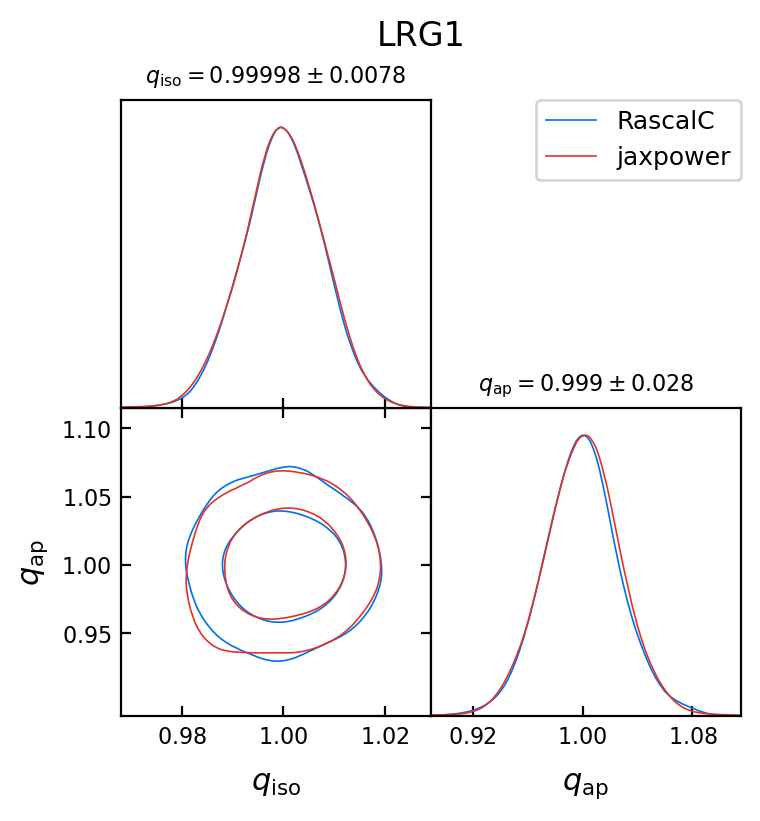

Removed no burn in
Removed no burn in


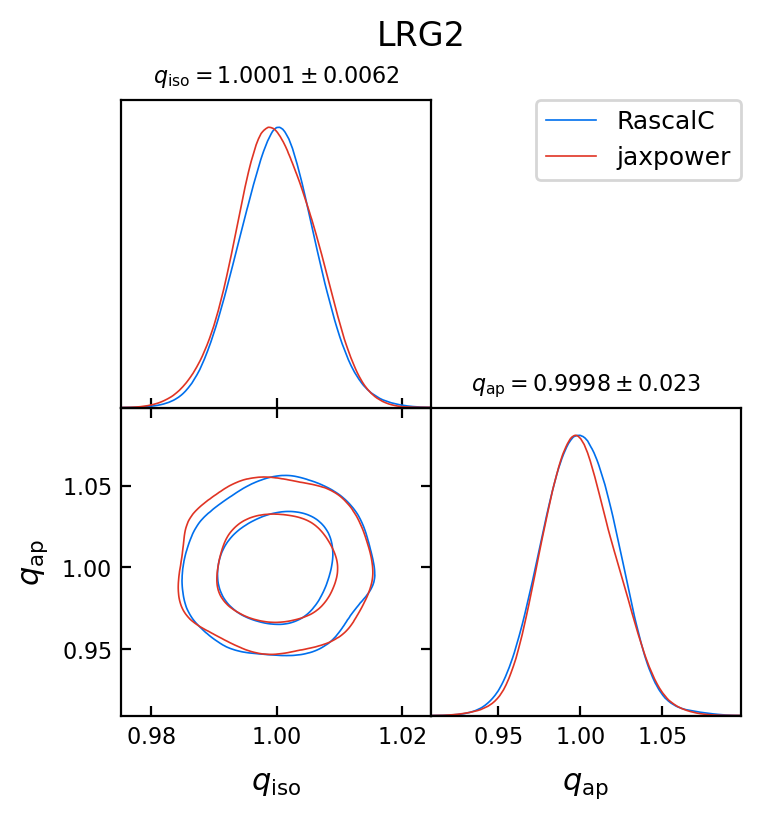

Removed no burn in
Removed no burn in


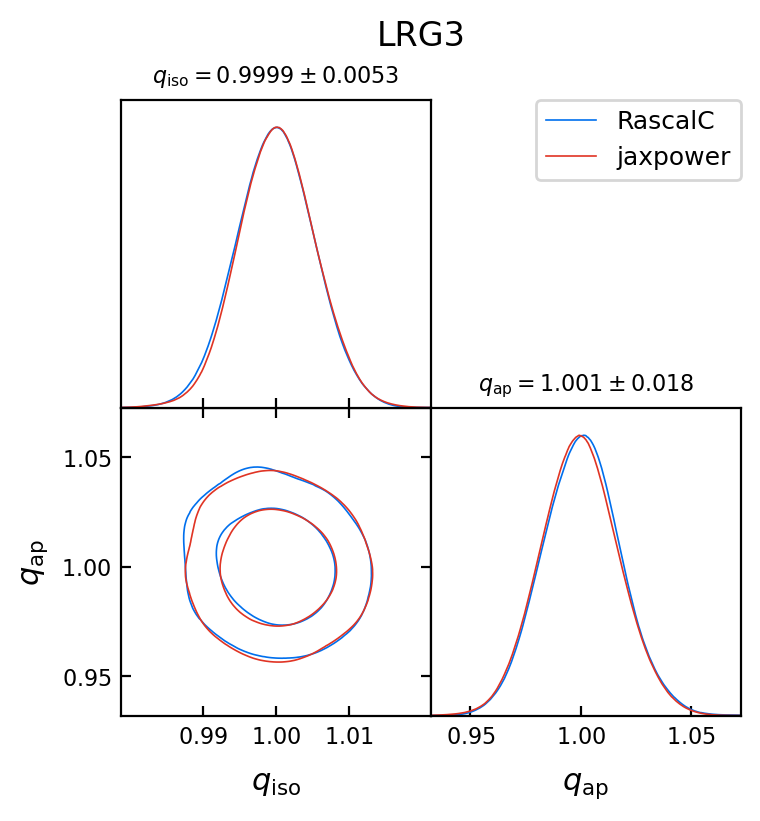

Removed no burn in
Removed no burn in


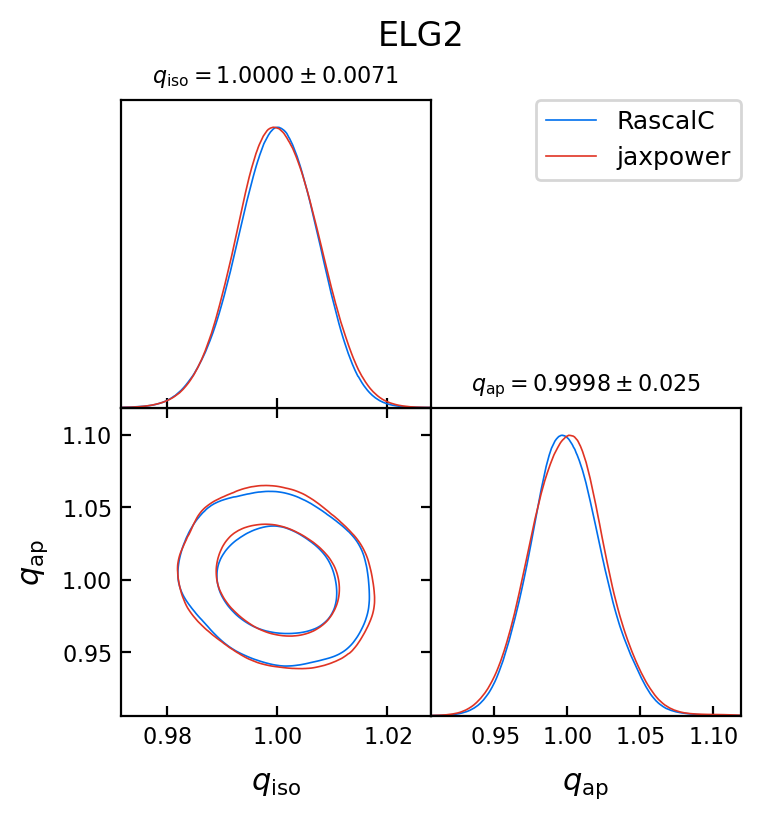

Removed no burn in
Removed no burn in


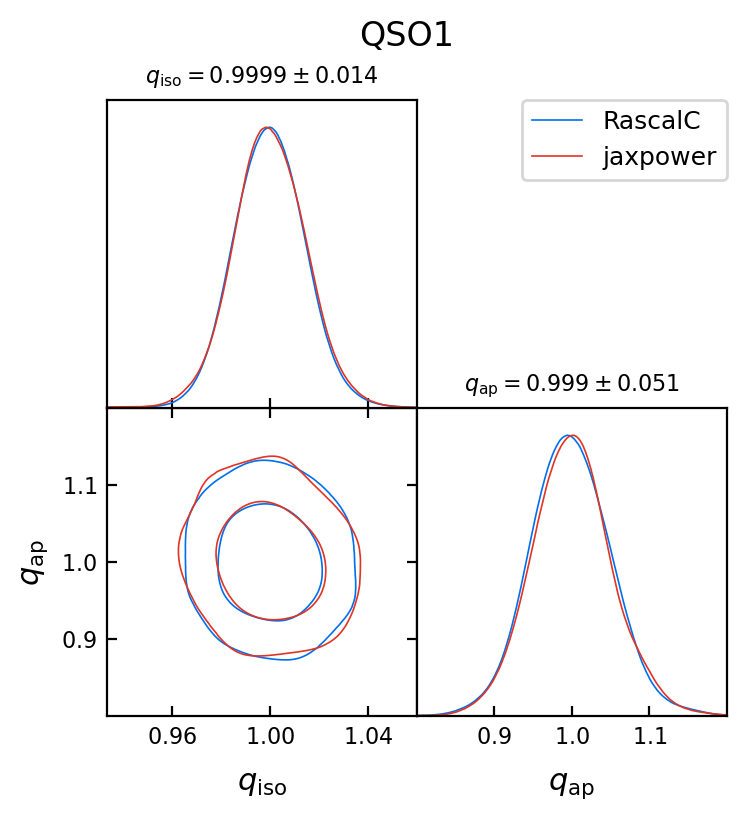

Tracer   qiso ratio   qap ratio
BGS1    0.918        0.913
LRG1    1.014        0.998
LRG2    1.037        0.987
LRG3    0.987        1.002
ELG2    1.021        1.048
QSO1    1.038        0.998


In [3]:
fits_dir = Path('/dvs_ro/cfs/cdirs/desi/science/cai/desi-clustering/dr2/fits/bao')
dir_dr2_centered = fits_dir / 'centered_alpha/data-dr2-v1.1'

stats = defaultdict(list)
tracers = []
for tracer, (basename_rascalc, basename_jaxpower) in {'BGS1': ('template-bao_BGS1-z0p1-0p4-GCcomb-C2R-04031e03', 'template-bao_BGS1-z0p1-0p4-GCcomb-C2R-81960a56'),
                                             'LRG1': ('template-bao_LRG1-z0p4-0p6-GCcomb-C2R-87f87260', 'template-bao_LRG1-z0p4-0p6-GCcomb-C2R-d0b68470'),
                                             'LRG2': ('template-bao_LRG2-z0p6-0p8-GCcomb-C2R-8910d425', 'template-bao_LRG2-z0p6-0p8-GCcomb-C2R-a9326aab'),
                                             'LRG3': ('template-bao_LRG3-z0p8-1p1-GCcomb-C2R-ceab2a2e', 'template-bao_LRG3-z0p8-1p1-GCcomb-C2R-ef1825f6'),
                                             'ELG2': ('template-bao_ELG2-z1p1-1p6-GCcomb-C2R-0813091f', 'template-bao_ELG2-z1p1-1p6-GCcomb-C2R-0a73e83c'),
                                             'QSO1': ('template-bao_QSO1-z0p8-2p1-GCcomb-C2R-1d44ab1f', 'template-bao_QSO1-z0p8-2p1-GCcomb-C2R-8eba6faa')}.items():
    samples, legends = [], []
    samples.append(read_samples([dir_dr2_centered / f'{basename_rascalc}/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.5, thin=10))
    legends.append('RascalC')
    samples.append(read_samples([dir_dr2_centered / f'{basename_jaxpower}/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.5, thin=10))
    legends.append('jaxpower')
    plotting.plot_triangle(samples, params=params_toplot, title_limit=1, markers=truth, legend_labels=legends)
    fig = plt.gcf()
    fig.suptitle(tracer)
    plt.show()
    tracers.append(tracer)
    for sample, label in zip(samples, legends):
        stats[(label, 'qiso')].append(sample.std('qiso'))
        stats[(label, 'qap')].append(sample.std('qap'))

ratio_qiso = np.array(stats[('jaxpower', 'qiso')]) / np.array(stats[('RascalC', 'qiso')])
ratio_qap  = np.array(stats[('jaxpower', 'qap')])  / np.array(stats[('RascalC', 'qap')])

print("Tracer   qiso ratio   qap ratio")
for tracer, rqiso, rqap in zip(tracers, ratio_qiso, ratio_qap):
    print(f"{tracer:5s}   {rqiso:.3f}        {rqap:.3f}")